# 1. Header with Contributions

## Analyzing NBA Data from 1996–2022  
### Fall 2025 Data Science Project  
**Allen Yoo, Jeffrey Deng, Keshav Narasimhan**

---

## Contribution Areas  
`A`: Project Idea  
`B`: Data Curation & Preprocessing  
`C`: Data Exploration & Summary Statistics  
`D`: ML Algorithm Design  
`E`: ML Training & Evaluation  
`F`: Visualization & Result Analysis  
`G`: Final Tutorial Report Creation  
`H`: Additional Contributions  

---

## Contributions

### Allen Yoo — `A`, `C`, `D`, `E`, `F`, `H`  
I conducted a Chi-Square Test of Independence to compare draft outcomes between USA and international players. I also built the Points Per Game (PPG) prediction model, which included preparing the dataset, selecting features, training and tuning a Random Forest regressor, evaluating model performance, and writing the Primary Analysis section.

### Jeffrey Deng — `A`, `B`, `C`, `F`, `G`, `H`  
I examined the linear relationship between player height and points per game (PPG) using Pearson’s correlation. I also made graphs to show off the feature importance and the accuracy of a Random Forest model. I wrote the final insights and conclusion for the entire project and published the project.

### Keshav Narasimhan — `A`, `B`, `C`, `E`, `F`, `G`
I developed the project idea, handled initial data preprocessing, and conducted early exploratory analysis. I cleaned country-of-origin data, examined height differences between countries with visualizations, built a random forest model for rebound prediction. I also created a bar graph highlighting the importance of different features in predicting rebounds per game., and contributed to writing the final tutorial.

---

# 2. Introduction

The NBA has become increasingly global and data-driven. Players now enter the league from many countries and bring a wide range of physical traits and playing styles. Understanding how these characteristics relate to on-court performance can help coaches, scouts, analysts, and fans make better evaluations.

In this project, we analyze NBA player data from 1996 to 2022 to explore how features like height, country of origin, shooting efficiency, and usage connect to performance. Our work focuses on two main goals:

1. **Exploratory Data Analysis**  
   We look for patterns in player characteristics and test relationships such as whether draft outcomes differ between USA and international players, or whether taller players tend to score more.

2. **Predictive Modeling**  
   We build a regression model to predict a player’s points per game (PPG) using variables such as minutes played, shooting efficiency, and play-style statistics.

By combining exploratory analysis with machine learning, we aim to understand which player attributes matter most for scoring and how accurately we can predict offensive performance in the NBA.

---

# 3. Data Curation

All of our data comes from the file **all_seasons.csv**, a Kaggle dataset containing about statistics for every NBA player from 1996 to 2022.

We load it into a Pandas DataFrame to inspect and summarize the data efficiently. Using functions such as `info()`, `describe()`, and `value_counts()`, we reviewed column types, checked for missing values, and gained an overview of the dataset's structure.

We also standardized several country labels to ensure consistent grouping in later analyses. The raw dataset includes duplicate or historical names for the same country, so we cleaned these entries to create a uniform set of categories.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df=pd.read_csv('all_seasons.csv')
df.head(5)

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         12844 non-null  int64  
 1   player_name        12844 non-null  object 
 2   team_abbreviation  12844 non-null  object 
 3   age                12844 non-null  float64
 4   player_height      12844 non-null  float64
 5   player_weight      12844 non-null  float64
 6   college            10990 non-null  object 
 7   country            12844 non-null  object 
 8   draft_year         12844 non-null  object 
 9   draft_round        12844 non-null  object 
 10  draft_number       12844 non-null  object 
 11  gp                 12844 non-null  int64  
 12  pts                12844 non-null  float64
 13  reb                12844 non-null  float64
 14  ast                12844 non-null  float64
 15  net_rating         12844 non-null  float64
 16  oreb_pct           128

In [ ]:
df.columns

Index(['Unnamed: 0', 'player_name', 'team_abbreviation', 'age',
       'player_height', 'player_weight', 'college', 'country', 'draft_year',
       'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating',
       'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season'],
      dtype='object')

In [ ]:
df.dtypes

,0
Unnamed: 0,int64
player_name,object
team_abbreviation,object
age,float64
player_height,float64
player_weight,float64
college,object
country,object
draft_year,object
draft_round,object


In [ ]:
df.describe()

,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,6421.500000,27.045313,200.555097,100.263279,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595
std,3707.887763,4.339211,9.111090,12.426628,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172
min,0.000000,18.000000,160.020000,60.327736,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3210.750000,24.000000,193.040000,90.718400,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000
50%,6421.500000,26.000000,200.660000,99.790240,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000
75%,9632.250000,30.000000,208.280000,108.862080,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000
max,12843.000000,44.000000,231.140000,163.293120,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
player_name,0
team_abbreviation,0
age,0
player_height,0
player_weight,0
college,1854
country,0
draft_year,0
draft_round,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['country'].nunique()


82

## Standardizing Country Labels

The raw dataset contains several inconsistent or historical country labels, such as “Congo” vs. “DRC,” “Bosnia” vs. “Bosnia & Herzegovina,” and legacy names like “Yugoslavia” or “Serbia and Montenegro.” To ensure that our hypothesis tests and visualizations group players correctly, we standardized these entries into a smaller set of consistent modern country names. This helps avoid splitting the same country across multiple labels and makes our analysis easier to interpret.

In [ ]:
# Standardize inconsistent country names

# US territories / punctuation
df['country'] = df['country'].replace('U.S. Virgin Islands', 'US Virgin Islands')

# Historical / split countries
df['country'] = df['country'].replace('Serbia and Montenegro', 'Serbia')

# Congo variants
df['country'] = df['country'].replace('Congo', 'Democratic Republic of the Congo')
df['country'] = df['country'].replace('DRC', 'Democratic Republic of the Congo')

# Bosnia variants
df['country'] = df['country'].replace('Bosnia', 'Bosnia and Herzegovina')
df['country'] = df['country'].replace('Bosnia & Herzegovina', 'Bosnia and Herzegovina')

# USSR simplified to a single modern label (all USSR labeled players in this dataset are Lithuanian)
df['country'] = df['country'].replace('USSR', 'Lithuania')

# Convert Sudan (UK) to South Sudan (treating historical labels as South Sudan)
df['country'] = df['country'].replace('Sudan (UK)', 'South Sudan')

# UK-related labels
df['country'] = df['country'].replace('England', 'United Kingdom')
df['country'] = df['country'].replace('Scotland', 'United Kingdom')

# Manually correct Yugoslavia-era players to their modern national teams
df.loc[df['player_name'] == 'Ratko Varda', 'country'] = 'Serbia'
df.loc[df['player_name'] == 'Zeljko Rebraca', 'country'] = 'Serbia'
df.loc[df['player_name'] == 'Predrag Drobnjak', 'country'] = 'Montenegro'
df.loc[df['player_name'] == 'Predrag Savovic', 'country'] = 'Montenegro'

In [ ]:
df['country'].nunique()

71

---

# 4. Exploratory Data Analysis

We conducted several statistical checks to explore relationships in the dataset:

- **Keshav:** Tested whether average player height differs across countries using a one-way ANOVA and visualizations.  
- **Jeffrey:** Examined the linear relationship between player height and points per game (PPG) using Pearson’s correlation.  
- **Allen:** Used a Chi-Square Test of Independence to evaluate whether draft status differs between USA and international players.

---

## Height vs Country of Origin  (Hypothesis Testing) [Keshav]

*   **$H_{0}$:** Country of origin has no effect on height of NBA players
*   **$H_{1}$:** Country of origin does have an effect on the height of NBA players

In [ ]:
# Check raw country labels
df.country.unique()

array(['USA', 'Nigeria', 'Democratic Republic of the Congo', 'Canada',
       'Serbia', 'Ukraine', 'Croatia', 'Jamaica', 'Lithuania', 'Slovenia',
       'US Virgin Islands', 'France', 'St. Vincent & Grenadines',
       'Germany', 'Dominican Republic', 'New Zealand', 'Georgia',
       'Belize', 'United Kingdom', 'Turkey', 'Greece', 'Finland',
       'Senegal', 'Mexico', 'Puerto Rico', 'China', 'Argentina', 'Mali',
       'Montenegro', 'Spain', 'Venezuela', 'Haiti', 'Russia', 'Brazil',
       'Ireland', 'Poland', 'Netherlands', 'Czech Republic', 'Latvia',
       'South Korea', 'Australia', 'Uruguay', 'South Sudan', 'Italy',
       'Switzerland', 'Gabon', 'Cameroon', 'Iran', 'Israel', 'Tanzania',
       'Sweden', 'Panama', 'Great Britain', 'Bosnia and Herzegovina',
       'Macedonia', 'Cabo Verde', 'Tunisia', 'Bahamas', 'Ghana',
       'Austria', 'Egypt', 'Trinidad and Tobago', 'Japan', 'Angola',
       'Saint Lucia', 'Sudan', 'Republic of the Congo', 'Guinea',
       'Denmark', 'Colombia

In [ ]:
# Group heights by country
grouped_by_country = df.groupby('country')

heights_by_country = {}

for country, group in grouped_by_country:
    unique_players_group = group.drop_duplicates(subset='player_name')
    heights_by_country[country] = unique_players_group['player_height'].tolist()

In [ ]:
# One-way ANOVA: Does height differ across countries?
fvalue, pvalue = stats.f_oneway(*heights_by_country.values())

print(f"ANOVA F-value: {fvalue}")
print(f"ANOVA p-value: {pvalue}")

alpha = 0.05
if pvalue < alpha:
    print("Reject the null hypothesis: There is a statistically significant difference in height between players from different countries.")
else:
    print("Fail to reject the null hypothesis: There is no statistically significant difference in height between players from different countries.")

ANOVA F-value: 3.7914238649916157
ANOVA p-value: 6.115196242766596e-23
Reject the null hypothesis: There is a statistically significant difference in height between players from different countries.


## Conclusion

The ANOVA test returned an F-value of 3.79 and a p-value of $6.11 \times 10^{-23}$. Because this p-value is far below the significance level of 0.05, we reject the null hypothesis. This result indicates that average player height differs significantly across countries.

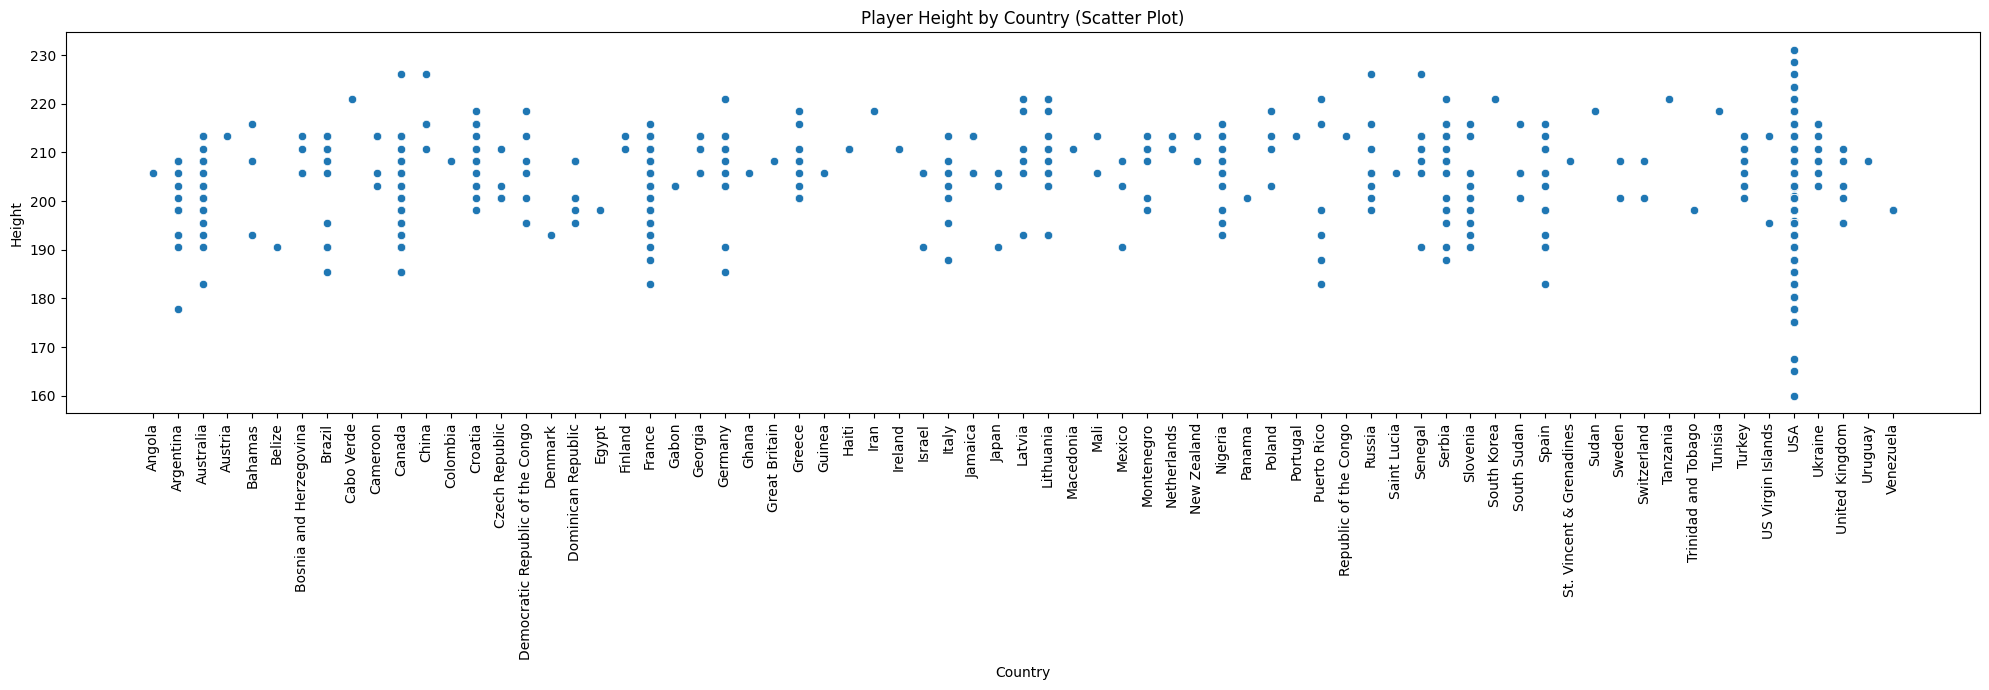

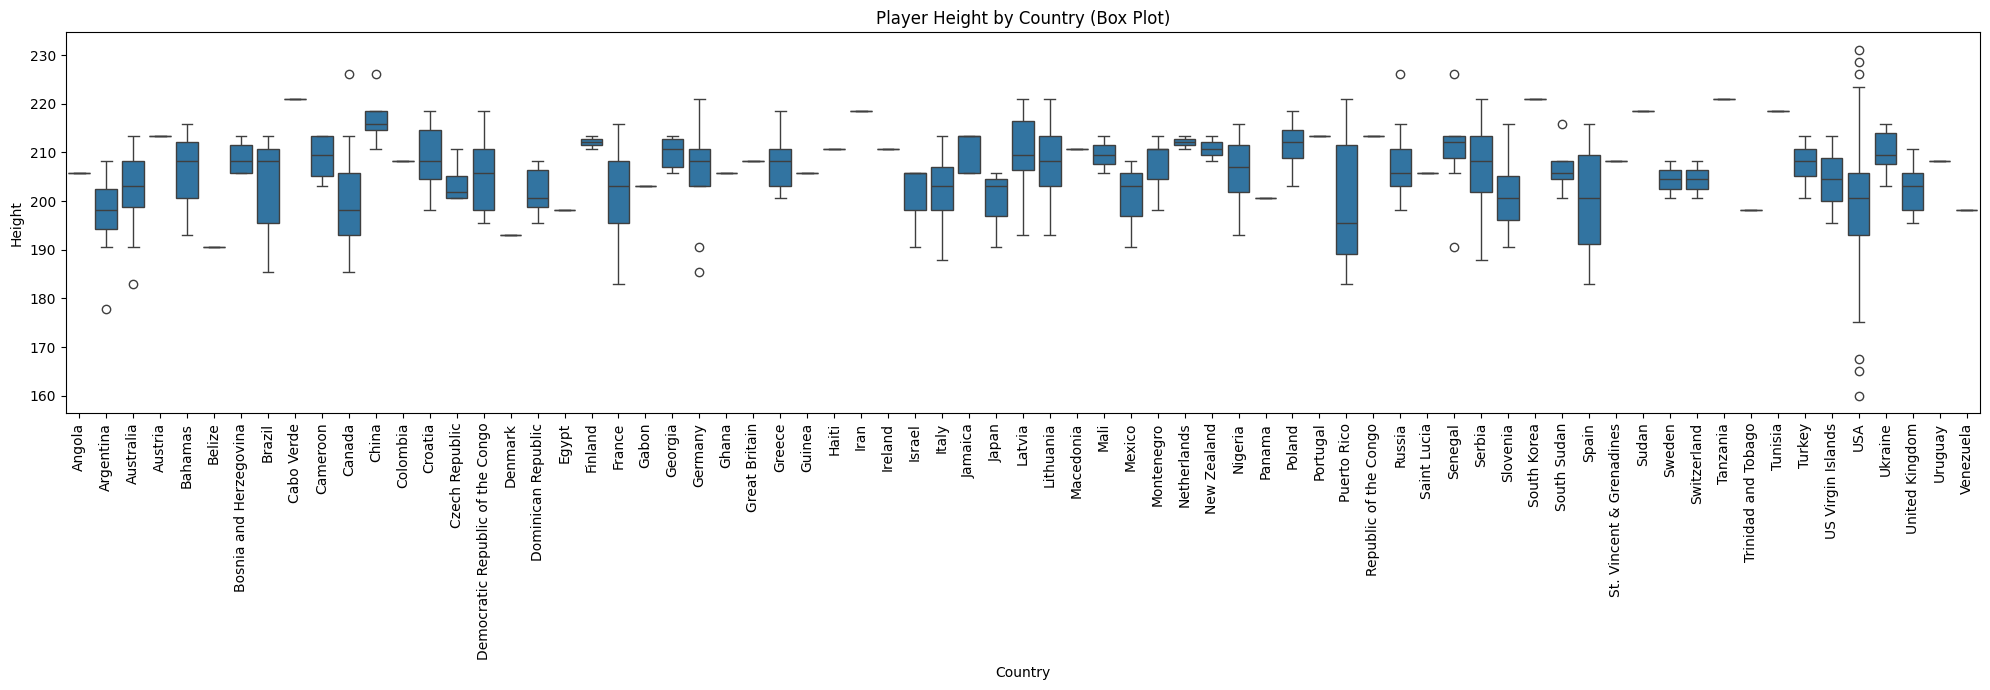

In [ ]:
# Prepare data for plotting
countries = list(heights_by_country.keys())
heights = [item for sublist in heights_by_country.values() for item in sublist]
country_labels = [country for country, height_list in heights_by_country.items() for _ in height_list]

# Create a DataFrame for easier plotting with seaborn
plot_df = pd.DataFrame({'Country': country_labels, 'Height': heights})

# Create a scatter plot
plt.figure(figsize=(20, 7))  # Increase figure width
sns.scatterplot(x='Country', y='Height', data=plot_df)
plt.title('Player Height by Country (Scatter Plot)')
plt.xticks(rotation=90)

plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.show()

# Create a box plot
plt.figure(figsize=(20, 7))  # Increase figure width
sns.boxplot(x='Country', y='Height', data=plot_df)
plt.title('Player Height by Country (Box Plot)')
plt.xticks(rotation=90)

plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.show()

---

## Height vs Points per Game (Pearson Correlation Test) [Jeffrey]

- **$H_{0}$:** There is no linear relationship between player height and points per game.
- **$H_{1}$:** There is a significant linear relationship between player height and points per game.

In [ ]:
# Keep only relevant numeric columns
cols = ['player_name', 'player_height', 'pts', 'season']
df_clean = df[cols].dropna(subset=['player_height', 'pts'])

# Average across seasons per player
player_avg = df_clean.groupby('player_name', as_index=False).agg({
    'player_height': 'first',
    'pts': 'mean'
})

player_avg.head()

r, p = pearsonr(player_avg['player_height'], player_avg['pts'])
print(f"Pearson r = {r:.3f}, p-value = {p:.3f}")

Pearson r = -0.041, p-value = 0.038


## Conclusion

The analysis gave us: Pearson r = -0.041 and p-value = 0.038. Although the p-value indicates statistical significance at the 0.05 level (allowing us to reject H₀), the magnitude of the correlation (r ≈ -0.041) is extremely small. This suggests that, while the relationship is statistically detectable due to the large dataset, it is not meaningful. In other words, a player’s height has virtually no linear association with their scoring average which implies that factors such as position, role, or playing style more likely to be the determinant of points per game.

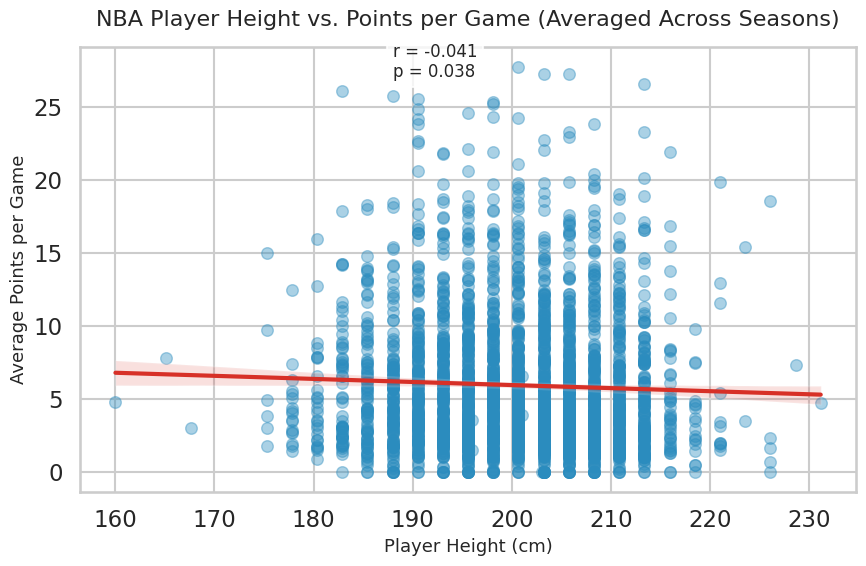

In [ ]:
sns.set_theme(style="whitegrid", context="talk", palette="deep")

plt.figure(figsize=(9,6))
sns.regplot(
    data=player_avg,
    x='player_height', y='pts',
    scatter_kws={'alpha':0.4, 's':70, 'color':'#2b8cbe'},
    line_kws={'color':'#d73027', 'lw':3}
)
plt.title('NBA Player Height vs. Points per Game (Averaged Across Seasons)', fontsize=16, pad=15)
plt.xlabel('Player Height (cm)', fontsize=13)
plt.ylabel('Average Points per Game', fontsize=13)
plt.text(188, 27, f'r = {r:.3f}\np = {p:.3f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()


---

## Draft Status: USA vs International Players (Chi-Square Test of Independence) [Allen]

- **$H_{0}$:** Draft status (drafted vs undrafted) is independent of country of origin.  
- **$H_{1}$:** Draft status is associated with country of origin (USA vs international).  

A Chi-Square Test of Independence will be used to determine whether draft outcomes differ significantly between USA and international players. If the p-value is less than 0.05, we reject **$H_{0}$**.


In [ ]:
# Data cleaning

# Only get values we need
df_clean = df[['player_name', 'country', 'draft_year']].copy()

# Consistent text style
df_clean['draft_year'] = df_clean['draft_year'].astype(str).str.strip().str.title()
df_clean['country'] = df_clean['country'].astype(str).str.strip().str.title()

# Map US territories to USA
us_territories = ['Us Virgin Islands', 'Puerto Rico', 'Guam', 'Northern Mariana Islands', 'American Samoa']
df_clean['country'] = df_clean['country'].replace(us_territories, 'Usa')

# Define binary columns
df_clean['is_drafted'] = df_clean['draft_year'] != 'Undrafted'
df_clean['is_usa'] = df_clean['country'] == 'Usa'

# Drop duplicate players
df_clean = df_clean.drop_duplicates(subset=['player_name']).reset_index(drop=True)

df_clean.head()

,player_name,country,draft_year,is_drafted,is_usa
0,Randy Livingston,Usa,1996,True,True
1,Gaylon Nickerson,Usa,1994,True,True
2,George Lynch,Usa,1993,True,True
3,George McCloud,Usa,1989,True,True
4,George Zidek,Usa,1995,True,True


In [ ]:
# Build contingency table
contingency = pd.crosstab(df_clean['is_usa'], df_clean['is_drafted'])

# Rename rows and columns for clarity
contingency.index = ['International', 'USA']
contingency.columns = ['Undrafted', 'Drafted']

print("=== Contingency Table: Country vs Draft Status ===\n")
print(contingency.to_string())
print("\n==============================================\n")

# Run Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.5f}\n")
print("==============================================\n")

# Show expected counts
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

# Interpretation
if p < 0.05:
    print("Reject null hypothesis => Draft status and country are significantly associated.")
else:
    print("Fail to reject null hypothesis => No significant relationship between draft status and country.")

=== Contingency Table: Country vs Draft Status ===

               Undrafted  Drafted
International        110      294
USA                  664     1483


Chi-square statistic: 2.030
Degrees of freedom: 1
p-value: 0.15423


Fail to reject null hypothesis => No significant relationship between draft status and country.


## Conclusion

A Chi-Square Test of Independence was conducted to examine whether draft status (drafted vs. undrafted) differs by country of origin (USA vs. international). The result was not statistically significant, $\chi^2(1, N = 2551) = 2.03$, $p = 0.154$, indicating no strong evidence that draft outcomes depend on country of origin.

In this dataset, **27.2%** of international players were undrafted compared to **30.9%** of USA players. The proportions are nearly identical, suggesting that players from both groups have comparable chances of being drafted.

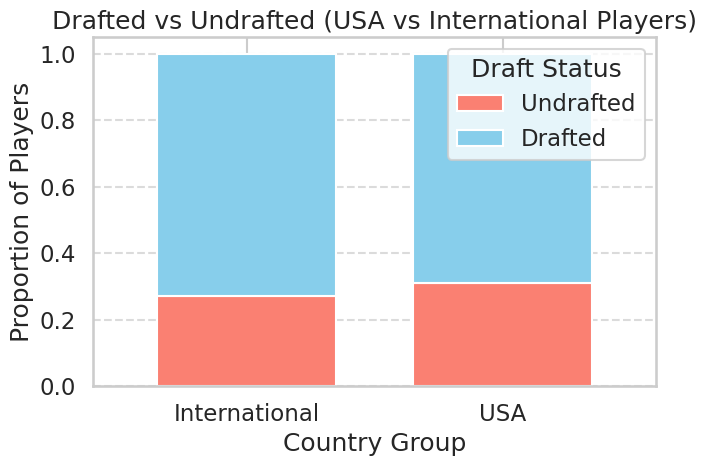

In [ ]:
# Compute proportions of drafted vs undrafted players
draft_rates = contingency.div(contingency.sum(axis=1), axis=0)

# Reindex so bars appear in logical order
draft_rates = draft_rates.reindex(['International', 'USA'])

# Plot stacked bar chart
ax = draft_rates.plot(
    kind='bar',
    stacked=True,
    color=['salmon', 'skyblue'],
    figsize=(7, 5),
    width=0.7
)

plt.title('Drafted vs Undrafted (USA vs International Players)')
plt.xlabel('Country Group')
plt.ylabel('Proportion of Players')
plt.legend(title='Draft Status', labels=['Undrafted', 'Drafted'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---

# 5. Primary Analysis (Part 1)

In this section, we built a machine learning model to answer our central question:

> **Can we accurately predict how many points per game (PPG) an NBA player scores?**

During exploratory analysis, we found that the dataset is heavily focused on offensive statistics such as `usg_pct`, `ts_pct`, `ast_pct`, and `orb_pct`. Because defensive data is extremely limited, predicting a blended metric like net rating would be hard. Therefore, focusing on PPG aligns directly with the strengths of our dataset.

---

## Selected Features
To model PPG, we selected features representing physical traits, opportunity, and offensive involvement:
- `age`  
- `player_height`  
- `player_weight`  
- `draft_round`  
- `usg_pct` (usage percentage)  
- `ts_pct` (true shooting percentage)  
- `ast_pct` (assist percentage)  
- `oreb_pct` (offensive rebound percentage)  

The target variable was:

- `pts` (PPG)

---

## Modeling Approach

Since PPG is a continuous variable, this is a **regression** problem. The CMSC320 slide deck ([Regression vs. Classification](https://docs.google.com/presentation/d/1gad8MGSo3oyg9Jp9SpZPsaWhR5vbFD0T/edit?slide=id.g33d355a89a6_0_0#slide=id.g33d355a89a6_0_0)) explains that **regression models predict real-valued outputs**, while classification models predict categorical outcomes. Because PPG is numeric, regression is the appropriate choice for this task.

To capture different types of relationships in the data, we trained two models:

- **Linear Regression** — provides a simple, interpretable baseline  
- **Random Forest Regression** — captures nonlinear relationships and interactions between features  

We evaluated both models using an **80/20 train–test split**, allowing us to measure generalization performance on unseen players from the same dataset.

---

## Analysis Goals

1. **Predictive Accuracy**  
   Evaluate how well our selected features can estimate a player's points per game.

2. **Feature Importance**  
   Identify which variables contribute most to scoring performance.  
   We interpret both linear model coefficients and Random Forest feature importances to understand linear and nonlinear effects.

---

## Data Cleaning and Feature Setup

This block prepares the dataset for modeling by cleaning up the draft_round column and selecting the features and target we’ll use in our machine learning models.

In [ ]:
df_pts_model = df.copy()   # keep original df safe

# 1) Drop unnamed columns
df_pts_model = df_pts_model.loc[:, ~df_pts_model.columns.str.contains('^Unnamed')]

# 2) Clean draft_round
# The raw draft_round column contains several values:
#   1, 2 → Real NBA draft rounds
#   0 → Undrafted players (data entry convention)
#   'Undrafted' → Explicit undrafted label
#   3, 4, 6, 7, 8 → Older NBA draft rounds (the NBA used to have up to 10 rounds)
#
# For machine learning, these extra rounds are extremely rare and represent
# players drafted much later than modern rounds. They behave more like
# undrafted players than true 1st/2nd round picks.
#
# To simplify the feature and avoid unnecessary noise, we collapse draft_round into:
#   1 → First-round picks
#   2 → Second-round picks
#   3 → All other cases (third round or later, plus undrafted)
#
# This keeps the feature meaningful while avoiding tiny categories.
df_pts_model['draft_round'] = df_pts_model['draft_round'].astype(str)
df_pts_model['draft_round'] = df_pts_model['draft_round'].apply(
    lambda x: 1 if x == '1' else (2 if x == '2' else 3)
)

# 3) Define features and target
features_pts = ['age', 'player_height', 'player_weight', 'draft_round',
                'usg_pct', 'ts_pct', 'ast_pct', 'oreb_pct']

target_pts = 'pts'

# 4) Quick checks
print("Draft round values:")
print(df_pts_model['draft_round'].value_counts().sort_index(), "\n")

print("Nulls in features:")
print(df_pts_model[features_pts].isnull().sum(), "\n")

print(f"Nulls in target ({target_pts}): {df_pts_model[target_pts].isnull().sum()}\n")

print("Data types:")
print(df_pts_model[features_pts + [target_pts]].dtypes)

Draft round values:
draft_round
1    7351
2    3032
3    2461
Name: count, dtype: int64 

Nulls in features:
age              0
player_height    0
player_weight    0
draft_round      0
usg_pct          0
ts_pct           0
ast_pct          0
oreb_pct         0
dtype: int64 

Nulls in target (pts): 0

Data types:
age              float64
player_height    float64
player_weight    float64
draft_round        int64
usg_pct          float64
ts_pct           float64
ast_pct          float64
oreb_pct         float64
pts              float64
dtype: object


## Train/Test Split

We split the data into training and test sets for model evaluation.

In [ ]:
# Create X (features) and y (target)
X_pts = df_pts_model[features_pts]
y_pts = df_pts_model[target_pts]

# Split: 80% train, 20% test
X_train_pts, X_test_pts, y_train_pts, y_test_pts = train_test_split(
    X_pts, y_pts, test_size=0.2, random_state=42
)

# Check the split
print(f"Training set: {len(X_train_pts)} rows")
print(f"Test set: {len(X_test_pts)} rows")

Training set: 10275 rows
Test set: 2569 rows


## Model 1: Linear Regression

Linear regression gives us a baseline for predicting PPG. It gets an $R^2$ of around **0.579**, which means it explains about 57.9% of the differences in player scoring. The average error is around **3.92 points** (RMSE) or **3.02 points** (MAE). This is fine but not great, which suggests we need a more complex non-linear model to capture the full picture.

In [ ]:
# Train the model
lr_model_pts = LinearRegression()
lr_model_pts.fit(X_train_pts, y_train_pts)

# Make predictions
y_pred_lr_pts = lr_model_pts.predict(X_test_pts)

# Evaluate
print("Linear Regression Results:\n")
print(f"R² Score:  {r2_score(y_test_pts, y_pred_lr_pts):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test_pts, y_pred_lr_pts)):.4f}")
print(f"MAE:       {mean_absolute_error(y_test_pts, y_pred_lr_pts):.4f}")

Linear Regression Results:

R² Score:  0.5792
RMSE:      3.9261
MAE:       3.0221


## Model 2: Random Forest

The Random Forest model performs better than linear regression, with an $R^2$ of around **0.787**. This means it explains about 78.7% of the differences in player scoring, an improvement over the linear model's 57.9%. The average error drops to around **2.78 points** (RMSE) or **2.07 points** (MAE). This shows that Random Forest captures non-linear patterns in the data that linear regression misses, making it a stronger model for predicting PPG.

In [ ]:
# Train the model
rf_model_pts = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42
)
rf_model_pts.fit(X_train_pts, y_train_pts)

# Make predictions
y_pred_rf_pts = rf_model_pts.predict(X_test_pts)

# Evaluate
print("Random Forest Results:\n")
print(f"R² Score:  {r2_score(y_test_pts, y_pred_rf_pts):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test_pts, y_pred_rf_pts)):.4f}")
print(f"MAE:       {mean_absolute_error(y_test_pts, y_pred_rf_pts):.4f}")

Random Forest Results:

R² Score:  0.7876
RMSE:      2.7898
MAE:       2.0723


## Feature Importance

To understand which factors matter most for predicting PPG, we examined the Random Forest model's feature importance scores.

The results show that **usage percentage** (52%) and **true shooting percentage** (28%) dominate the model—together accounting for about 80% of the predictive power. This makes sense: players who take more shots (`usg_pct`) and make them efficiently (`ts_pct`) naturally score more points.

In [ ]:
importance_df_pts = pd.DataFrame({
    'Feature': features_pts,
    'Importance': rf_model_pts.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance:\n")
print(importance_df_pts.to_string(index=False))

Random Forest Feature Importance:

      Feature  Importance
      usg_pct    0.521790
       ts_pct    0.277149
      ast_pct    0.056713
     oreb_pct    0.048312
  draft_round    0.042837
          age    0.020080
player_weight    0.020027
player_height    0.013092



# Random Forest and Regression Models for Rebound Percentage

 Based on our process for points, we wanted to create a random forest regression model that analyzed just the draft round, the age, the weight, and the height of players, and we wanted to see how those characteristics affected rebounds per game. For these models, we decided to do splits based on years, with 2022 being the test year and the rest being training years.

**Critical Question: Can we create a model that accurately predicts rebounds per game for a given NBA player, and can we identify the features that are most important for this model?**


In [ ]:
df_ml_rebounds=df.copy()
df_ml_rebounds['draft_round']=df_ml_rebounds['draft_round'].replace('Undrafted', 3)
df_ml_rebounds['draft_round']=df_ml_rebounds['draft_round'].astype(int)

In [ ]:
#features are age, player_height, player_weight, draft_round
# target=rebounds per game
features=['age', 'player_height', 'player_weight', 'draft_round']
target='reb'

#change year column from YYYY-MM to YYYY format for all years.
df_ml_rebounds['season']=df_ml_rebounds['season'].str[:4]

df_ml_rebounds['season']=df_ml_rebounds['season'].astype(int)
df_ml_rebounds

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,12839,Joel Embiid,PHI,29.0,213.36,127.005760,Kansas,Cameroon,2014,1,...,33.1,10.2,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022
12840,12840,John Butler Jr.,POR,20.0,213.36,86.182480,Florida State,USA,Undrafted,3,...,2.4,0.9,0.6,-16.1,0.012,0.065,0.102,0.411,0.066,2022
12841,12841,John Collins,ATL,25.0,205.74,102.511792,Wake Forest,USA,2017,1,...,13.1,6.5,1.2,-0.2,0.035,0.180,0.168,0.593,0.052,2022
12842,12842,Jericho Sims,NYK,24.0,208.28,113.398000,Texas,USA,2021,2,...,3.4,4.7,0.5,-6.7,0.117,0.175,0.074,0.780,0.044,2022


In [ ]:
df_ml_rebounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12844 entries, 0 to 12843
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         12844 non-null  int64  
 1   player_name        12844 non-null  object 
 2   team_abbreviation  12844 non-null  object 
 3   age                12844 non-null  float64
 4   player_height      12844 non-null  float64
 5   player_weight      12844 non-null  float64
 6   college            10990 non-null  object 
 7   country            12844 non-null  object 
 8   draft_year         12844 non-null  object 
 9   draft_round        12844 non-null  int64  
 10  draft_number       12844 non-null  object 
 11  gp                 12844 non-null  int64  
 12  pts                12844 non-null  float64
 13  reb                12844 non-null  float64
 14  ast                12844 non-null  float64
 15  net_rating         12844 non-null  float64
 16  oreb_pct           128

In [ ]:
train_df=df_ml_rebounds[df_ml_rebounds['season']<2022]
test_df=df_ml_rebounds[df_ml_rebounds['season']==2022]

X_train=train_df[features]
y_train=train_df[target]
X_test=test_df[features]
y_test=test_df[target]



In [ ]:
preprocessor=ColumnTransformer(
    transformers=[('num', StandardScaler(), ['age', 'player_height', 'player_weight'])
    ],
    remainder= 'passthrough'
  )
pipeline=Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ]
)
pipeline.fit(X_train, y_train)
y_pred=pipeline.predict(X_test)

test_df['predicted_rebs']=y_pred

r2=r2_score(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

print(test_df[['age', 'player_height', 'player_weight', 'draft_round', 'reb', 'predicted_rebs']])


R-squared: 0.23
Mean Squared Error: 4.25
Mean Absolute Error: 1.54
        age  player_height  player_weight  draft_round   reb  predicted_rebs
12305  23.0         195.58      95.254320            1   3.2        2.766780
12306  24.0         195.58      78.471416            3   0.9        4.885467
12307  30.0         195.58      94.800728            2   4.6        2.719500
12308  23.0         198.12      97.068688            1   5.0        4.317119
12309  23.0         203.20     102.058200            1   6.0        3.989467
...     ...            ...            ...          ...   ...             ...
12839  29.0         213.36     127.005760            1  10.2        4.010850
12840  20.0         213.36      86.182480            3   0.9        2.179000
12841  25.0         205.74     102.511792            1   6.5        5.387677
12842  24.0         208.28     113.398000            2   4.7        2.942942
12843  33.0         205.74     102.965384            3   3.6        5.173700

[539 row

/tmp/ipython-input-1688475876.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_rebs']=y_pred


As evidenced by this random forest model, age, weight, height, and draft round can only explan 23% of the variance in rebounds per game. It is best to try another feature to understand what truly affects rebounds. I decided to do a linear regression model between usg_pct and rebounds per game. For this model, I used the same split, with 2022 being test data and the rest being training data.

In [ ]:
X=df_ml_rebounds[['usg_pct']]
y=df_ml_rebounds['reb']

train_df=df_ml_rebounds[df_ml_rebounds['season']<2022]
test_df=df_ml_rebounds[df_ml_rebounds['season']==2022]

X_train=train_df[features]
y_train=train_df[target]
X_test=test_df[features]
y_test=test_df[target]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")


R-squared: 0.45
Mean Squared Error: 3.03
Mean Absolute Error: 1.29


The R-squared value rises considerably, from 0.23 to 0.45  Finally, I will try a random forest with all the features, and do a feature importance analysis for rebounds.

## Selected Features
- `age`  
- `player_height`  
- `player_weight`  
- `draft_round`  
- `usg_pct` (usage percentage)  
- `ts_pct` (true shooting percentage)  
- `ast_pct` (assist percentage)  

## target
- `reb`

In [ ]:
# all numerical features except
features= ['age', 'player_height', 'player_weight', 'draft_round',
                'usg_pct', 'ts_pct', 'ast_pct']
target='reb'

train_df=df_ml_rebounds[df_ml_rebounds['season']<2022]
test_df=df_ml_rebounds[df_ml_rebounds['season']==2022]

X_train=train_df[features]
y_train=train_df[target]
X_test=test_df[features]
y_test=test_df[target]

In [ ]:
preprocessor=ColumnTransformer(
    transformers=[('num', StandardScaler(), ['age', 'player_height', 'player_weight', 'usg_pct', 'ts_pct', 'ast_pct'])
    ],
    remainder= 'passthrough'
  )
pipeline=Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ]
)
pipeline.fit(X_train, y_train)
y_pred=pipeline.predict(X_test)

test_df['predicted_rebs']=y_pred

r2=r2_score(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)

print(f"R-squared: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

print(test_df[['age', 'player_height', 'player_weight', 'draft_round', 'reb', 'predicted_rebs']])

R-squared: 0.54
Mean Squared Error: 2.51
Mean Absolute Error: 1.17
        age  player_height  player_weight  draft_round   reb  predicted_rebs
12305  23.0         195.58      95.254320            1   3.2           3.147
12306  24.0         195.58      78.471416            3   0.9           2.498
12307  30.0         195.58      94.800728            2   4.6           2.420
12308  23.0         198.12      97.068688            1   5.0           4.608
12309  23.0         203.20     102.058200            1   6.0           4.120
...     ...            ...            ...          ...   ...             ...
12839  29.0         213.36     127.005760            1  10.2          11.186
12840  20.0         213.36      86.182480            3   0.9           2.007
12841  25.0         205.74     102.511792            1   6.5           4.633
12842  24.0         208.28     113.398000            2   4.7           2.500
12843  33.0         205.74     102.965384            3   3.6           4.406

[539 row

/tmp/ipython-input-1568196396.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_rebs']=y_pred


This random forest model has the highest R-squared value, and the lowest error statistics. In order to examine what features made the difference, I also decided to do a feature analysis.

In [ ]:
importance_df_rebounds = pd.DataFrame({
    'Feature': features,
    'Importance': pipeline.named_steps['regressor'].feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance:\n")
print(importance_df_rebounds.to_string(index=False))

Random Forest Feature Importance:

      Feature  Importance
player_weight    0.258861
      usg_pct    0.240512
  draft_round    0.168534
       ts_pct    0.128047
player_height    0.079888
          age    0.067282
      ast_pct    0.056876


Unlike the points per game model, this model really has 4 features that account for 80% of the predictive power. These features are the player_weight, usg_pct, draft_round, and ts_pct. I must admit that I am surprised that player_weight has much more of an influence on the model compared to player height. However, this does make sense, as stronger players, like guards, can out muscle their competition to collect rebounds, wheras scoring can be done by quick shooters and physical guards.

---
#6. Visualization
This section focuses on the visualization of the results of the Primary Analysis.

# Feature Importance for PPG
The feature importance plot shows that the Random Forest model relies overwhelmingly on two variables—usage percentage (usg_pct) and true shooting percentage (ts_pct)—to predict how many points per game an NBA player scores. Usage percentage contributes over half of the model’s predictive power, reflecting that players who handle the ball and finish more possessions naturally have more scoring opportunities. True shooting percentage is the second most important factor, indicating that scoring efficiency (including 3-pointers and free throws) also plays a major role. Together, these two features explain roughly 80% of the model’s decision-making. The remaining features—assist percentage, offensive rebound percentage, draft round, age, height, and weight—have much smaller impacts, suggesting that once the model knows a player’s shooting volume and efficiency, physical traits and background contribute very little additional predictive value. Overall, the plot confirms a clear pattern: NBA scoring is driven primarily by how often a player shoots and how efficiently they score.

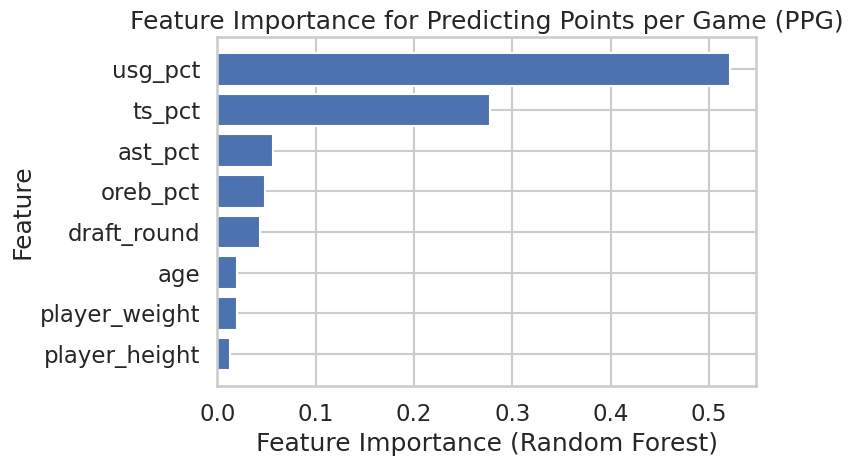

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Rebuild feature importance DF (ensures variable exists)
importance_df_pts = pd.DataFrame({
    'Feature': features_pts,
    'Importance': rf_model_pts.feature_importances_
})

# Sort for horizontal bar plot
importance_sorted = importance_df_pts.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_sorted['Feature'], importance_sorted['Importance'])
plt.xlabel('Feature Importance (Random Forest)')
plt.ylabel('Feature')
plt.title('Feature Importance for Predicting Points per Game (PPG)')
plt.tight_layout()
plt.show()

# Random Forest Model Accuracy: Actual vs. Predicted PPG
The scatter plot compares the Random Forest model’s predicted points per game (PPG) to the actual PPG values for players in the test set. Each point represents one player-season, and the dashed 45-degree line shows where perfect predictions would fall. Most of the points cluster tightly around this line, indicating that the model is able to estimate scoring output with strong accuracy. The performance metrics reinforce this: an R² of 0.788 means the model explains about 79% of the variation in player scoring, while the RMSE (2.79) and MAE (2.07) show that predictions are typically within about 2–3 points of a player’s true scoring average. Although a few outliers exist—reflecting players with unusual roles or inconsistent scoring—the overall pattern demonstrates that the Random Forest captures the key drivers of PPG and generalizes well to unseen players.

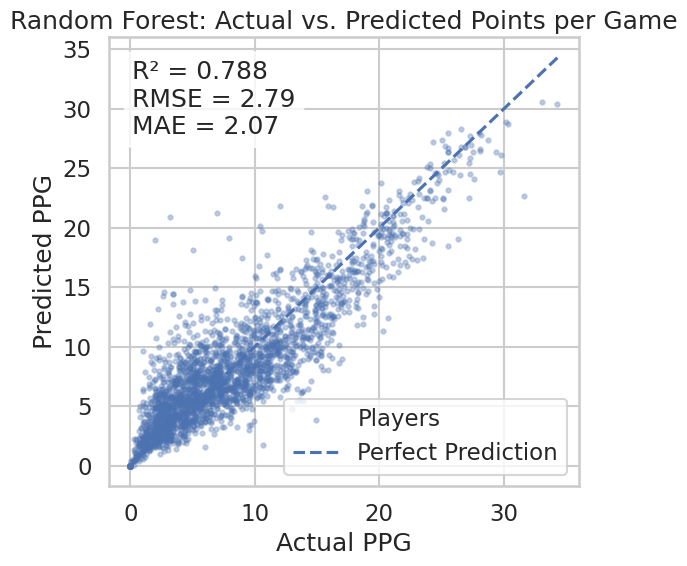

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Compute evaluation metrics
rf_r2 = r2_score(y_test_pts, y_pred_rf_pts)
mse = mean_squared_error(y_test_pts, y_pred_rf_pts)
rf_rmse = np.sqrt(mse)
rf_mae = mean_absolute_error(y_test_pts, y_pred_rf_pts)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_pts, y_pred_rf_pts, alpha=0.3, s=10, label='Players')

# 45-degree "perfect prediction" line
min_val = min(y_test_pts.min(), y_pred_rf_pts.min())
max_val = max(y_test_pts.max(), y_pred_rf_pts.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual PPG')
plt.ylabel('Predicted PPG')
plt.title('Random Forest: Actual vs. Predicted Points per Game')

# Add metrics box
textstr = f'R² = {rf_r2:.3f}\nRMSE = {rf_rmse:.2f}\nMAE = {rf_mae:.2f}'
plt.gca().text(
    0.05, 0.95, textstr,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)


plt.tight_layout()
plt.legend(loc='lower right')
plt.show()

# Feature Importance for Rebounds
The Random Forest model for predicting rebounds per game achieved an R² of 0.54, meaning it explains just over half of the variation in player rebounding, which is reasonable given the smaller feature set. The feature importance plot shows that player_weight is the most influential predictor, followed closely by usg_pct. Heavier players tend to be stronger rebounders, which aligns with the physical nature of rebounding, while higher usage often indicates players who are on the court more and involved in plays, increasing opportunities for rebounds. Draft_round and ts_pct also contribute moderately, suggesting that higher-tier prospects and more efficient players have somewhat more consistent rebounding roles. In contrast, player_height, age, and ast_pct have smaller importance scores. Height matters, but in this dataset it appears to be less predictive than strength/weight, and assist rate has little direct connection to rebounding. Overall, the model indicates that rebounding is driven more by physical build and playing opportunity than by shooting or playmaking skills, and while the model performs reasonably well, rebounds are harder to predict than scoring due to their reliance on game context, team systems, and role-specific responsibilities.

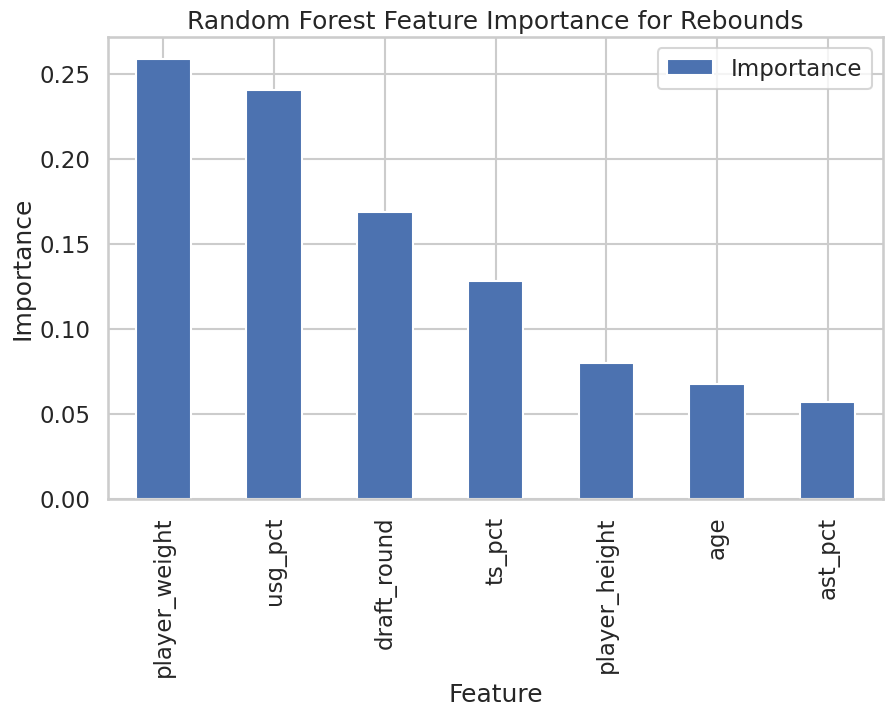

In [ ]:
# Bar plot for random forest for rebounds
import matplotlib.pyplot as plt

importance_df_rebounds.plot(kind='bar', x='Feature', y='Importance', figsize=(10, 6))
plt.title('Random Forest Feature Importance for Rebounds')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

---
# 7. Insights and Conclusions

Overall, the analysis provides a clear and coherent picture of what factors drive NBA player performance - both in scoring and rebounding - and demonstrates how statistical tests and machine learning models can uncover patterns in a large dataset. For a reader who is new to the topic, the project explains each step in a logical and easy to understand way: how the data was prepared, why certain features were chosen, how the models work, and what the results mean in a basketball context. For a reader familiar with basketball analytics, the project offers deeper insights into how usage, efficiency, physical traits, and opportunity shape player outcomes, supported by statistical evidence rather than just intuition.

Our exploratory analysis highlighted important structural patterns in the data. The ANOVA test showed that average player height differs significantly across countries, confirming that international leagues and the NBA pipeline tend to produce players with different physical profiles. Pearson’s correlation analysis showed that height has essentially no linear relationship with scoring (r ≈ –0.041), reminding us that scoring is driven more by role and playstyle than by raw size. The Chi-Square test further revealed that draft outcomes do not differ meaningfully between U.S. and international players, with nearly identical undrafted rates, showing that talent evaluation appears consistent across origins.

Our primary machine learning results give an even clearer picture of what drives on-court performance. For points per game (PPG), the Random Forest model achieved strong accuracy (R² ≈ 0.79), and the feature importance plot showed that usage percentage and true shooting percentage dominate scoring prediction, together accounting for about 80% of the model’s decision-making. This aligns with modern analytics: players score more when they shoot often and convert efficiently. Physical attributes such as height and weight contributed very little once these offensive metrics were known.

For rebounds, the Random Forest model performed moderately well (R² ≈ 0.54), and the feature importance results reflected the physical nature of rebounding. Player weight was the top predictor, followed by usage and draft round. Height mattered, but less than expected, suggesting that strength and opportunity are more reliable indicators of rebounding success in this dataset. This analysis shows that while rebounds are more context-dependent and thus harder to predict, measurable physical traits still provide substantial signal.

All together, these findings offer meaningful conclusions for both data science and basketball audiences. Our statistical tests reveal real structural differences in player backgrounds, while our models illuminate the key drivers of scoring and rebounding at the NBA level. More importantly, the project demonstrates how combining EDA with machine learning leads to insights that neither approach could reveal alone. An uninformed reader walks away understanding not just what predicts performance, but also why. An informed reader gains a more nuanced, data-driven understanding of NBA player metrics.